<a href="https://colab.research.google.com/github/immin0241/school_projects/blob/master/3_2_bigdata/bigdata_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# 필요한 라이브러리 import

import pandas as pd
import polars as pl
import numpy as np
import seaborn as sns
from glob import glob
from io import StringIO
import matplotlib.pyplot as plt
import os
from datetime import datetime, timedelta
from google.colab import userdata
import requests
from pathlib import Path

In [2]:
# 단계 1: 폰트 설치
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

!apt-get -qq -y install fonts-nanum > /dev/null



fe = fm.FontEntry(
    fname=r'/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf', # ttf 파일이 저장되어 있는 경로
    name='NanumGothic')                        # 이 폰트의 원하는 이름 설정
fm.fontManager.ttflist.insert(0, fe)              # Matplotlib에 폰트 추가
plt.rcParams.update({'font.size': 18, 'font.family': 'NanumGothic'}) # 폰트 설정

In [ ]:
# 단계 2: 런타임 재시작
import os
os.kill(os.getpid(), 9)

In [8]:
# 단계 3: 한글 폰트 설정
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm

# 마이너스 표시 문제
mpl.rcParams['axes.unicode_minus'] = False

# 한글 폰트 설정
fe = fm.FontEntry(
    fname=r'/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf', # ttf 파일이 저장되어 있는 경로
    name='NanumGothic')                        # 이 폰트의 원하는 이름 설정
fm.fontManager.ttflist.insert(0, fe)              # Matplotlib에 폰트 추가
plt.rcParams.update({'font.size': 12, 'font.family': 'NanumGothic'}) # 폰트 설

# 종관기상관측 데이터 전처리

- 시간별로 기온, 습도, 기압, 강수량 등의 데이터가 담겨있는 데이터입니다.
- 기상청의 API를 활용하여 한 리퀘스트에 한달의 데이터, 총 3년(2021~2024)의 데이터를 수집합니다.
- 추후 오염물질 데이터와 합치기 위해 관측소 정보를 같이 요청하여 merge해 하나의 데이터프레임으로 만듭니다.
- 데이터가 fsf(고정 공백으로 구분된 데이터) 형식으로 이루어져있고, 데이터 자체의 크기도 크므로 Out of Memory(OOM)을 방지하기 위해 필요없는 컬럼을 제거하고, Parquet으로 변환하여 크기를 줄였습니다.

In [4]:
#########
# 기상청 api를 사용해서 특정 연, 월의 종관기상관측 데이터를 수집
#########
KMA_API_KEY = userdata.get('KMA_API_KEY')

def get_asos(year, month):
  # 특정 연월의 마지막 일 구하기
  first_day = datetime(year, month, 1).strftime("%Y%m%d")
  if month == 12:
    last_day = (datetime(year + 1, 1, 1) - timedelta(days=1)).strftime("%Y%m%d")
  else:
    last_day = (datetime(year, month + 1, 1) - timedelta(days=1)).strftime("%Y%m%d")

  # Request 주소
  url = f"https://apihub.kma.go.kr/api/typ01/url/kma_sfctm3.php?tm1={first_day}0000&tm2={last_day}2300&help=0&authKey={KMA_API_KEY}"

  #GET 방식으로 fetch 후 response 반환
  response = requests.get(url)

  if response.status_code != 200:
   print(f"Error: 요청에 실패하였습니다 ({response.status_code})")
   return ''

  result = response.text

  return result

In [7]:
!du -h /content/temperature_20210101_20231231.txt

642M	/content/temperature_20210101_20231231.txt


In [9]:
start_date = datetime(2021, 1, 1)
end_date = datetime(2023, 12, 31)

current_date = start_date
data_buffer = []

while current_date <= end_date:
  print(f"{current_date.year}년 {current_date.month}월 데이터 수집 중...")

  raw_data = get_asos(current_date.year, current_date.month)

  # 데이터에서 주석 제거
  lines = raw_data.splitlines()[4:-1]
  raw_clean = "\n".join(lines)

  # 텍스트 버퍼에 클린한 텍스트 추가
  data_buffer.append(raw_clean)

  # 다음 날짜로 진행
  if current_date.month == 12:
    current_date = datetime(current_date.year + 1, 1, 1)
  else:
    current_date = datetime(current_date.year, current_date.month + 1, 1)

# 수집한 데이터 저장
complete_temp_data = "\n".join(data_buffer)

with open('/content/temperature_20210101_20231231.txt', "w") as fp:
  fp.write(complete_temp_data)
  del data_buffer
  del complete_temp_data

In [10]:
############
# 지상 관측소 정보 api로 가져오기
############

station_info_url = "https://apihub.kma.go.kr/api/typ01/url/stn_inf.php?inf=SFC&stn=&tm=202211300900&authKey=" + KMA_API_KEY

response = requests.get(station_info_url)

raw_clean_response = response.text.splitlines()[3:-1]
clean_response = "\n".join(raw_clean_response)

station_df = pd.read_fwf(StringIO(clean_response), colspecs='infer', header=None, infer_nrows=100)

station_df = station_df[[0,10]]

station_df.columns = ['측정소ID','측정소명']

In [12]:
#######
# 종관기상관측 데이터 전처리
#######


# 청킹한 파일을 저장할 디렉터리 생성
os.makedirs("/content/clean_asos", exist_ok=True)

# 위에서 청킹한 데이터 읽기
with open('/content/temperature_20210101_20231231.txt', 'r') as fp:
  complete_temp_data = fp.read()

# pd.read_fwf = 공백으로 구분된 데이터를 읽어들이는 pandas 함수
# 한 청크당 20만 row며, 공백 값은 상위 100줄에서 읽어들여 추론하도록 설정
chunks = pd.read_fwf(StringIO(complete_temp_data), colspecs='infer', header=None, infer_nrows=100, chunksize=200000)

# 기상청 api는 결측값(None)을 -9, -99, -999 등의 값으로 저장함
null_values = [-9, -9.0, -99.0, -999.0]

i = 0
for chunk in chunks:
  print(f"{i*200000} ~ {(i+1)*200000 - 1} 청크 처리 중...")
  # 필요없는 컬럼 제거 후 숫자 인덱스 -> 텍스트 인덱스로 변경
  chunk = chunk[[0, 1, 2, 3, 7, 11, 14]]
  chunk.columns = ["시간", "측정소ID", "풍향", "풍속", "온도", "상대습도", "강수량"]

  # Datetime으로 변환
  chunk['시간'] = pd.to_datetime(chunk['시간'], format="%Y%m%d%H%M")

  # 결측값들 실제 nan 값으로 대체
  chunk = chunk.replace(null_values, np.nan)

  # 측정소 정보와 ASOS 데이터 병합
  chunk = pd.merge(left=chunk, right=station_df, how="inner", on="측정소ID")

  # 측정소명 외 다른 컬럼들 float32화
  for col in chunk.columns:
    if col == '측정소명':
        continue
    if col != '시간':
        chunk[col] = chunk[col].astype("float32")

  # 데이터 정렬
  chunk = chunk.sort_values(by=['시간', '측정소ID'], ascending=True)

  # chunk를 parquet 형식으로 저장
  chunk.to_parquet(f"/content/clean_asos/chunk_{str(i).zfill(2)}.parquet")
  i += 1

# parquet 형식으로 저장된 청크들을 하나의 큰 파일로 다시 저장
files = glob("/content/clean_asos/*.parquet")
df = pl.concat([pl.read_parquet(f) for f in files])
df.write_parquet("/content/asos_dataframe.parquet")


# 에어코리아 데이터 전처리
- 에어코리아 홈페이지에서 제공하는 2021년~2023년의 '최종확정 측정자료' 를 사용하였습니다.
- 시간별로 국내 여러 관측소에서 측정한 오염물질 정보가 담겨있는 데이터입니다.
- 년월별로 총 36개의 파일이 있으므로 하나의 파일로 merging하는 과정을 거칩니다.
- 데이터가 xlsx 형식으로 이루어져있으므로 크기를 줄이기 위해 parquet 파일로 변환합니다.

In [19]:
# 데이터가 zip 형식으로 제공되므로 unzip 후 파일명 일관화

!unzip /content/2021.zip -d /content/pollutions/
!unzip /content/2022.zip -d /content/pollutions/
!unzip /content/2023.zip -d /content/pollutions/

!mv /content/pollutions/*/* /content/pollutions/
!rm -r /content/pollutions/2021 /content/pollutions/2022 /content/pollutions/2023

pol_glob = glob("/content/pollutions/*")

for name in pol_glob:
  tmp = name.split(" ")
  tmp[1] = ("0" if len(tmp[1]) == 7 else "") + tmp[1]
  os.rename(name, " ".join(tmp))

mv: cannot stat '/content/pollutions/*/*': No such file or directory


In [29]:
os.makedirs("clean_airkorea", exist_ok=True)

pollution_files = sorted(glob("/content/pollutions/*.xlsx"))

i = 0

for f in pollution_files:
    print("processing:", f)

    df = pd.read_excel(f, header=0)

    df = df[df['망'] == '도시대기'][['측정일시', '지역', 'PM10', 'PM25']]

    df['PM10'] = pd.to_numeric(df['PM10'], errors='coerce').astype("float32")
    df['PM25'] = pd.to_numeric(df['PM10'], errors='coerce').astype("float32")
    df['측정일시'] = pd.to_datetime(df['측정일시'], format="%Y%m%d%H", errors='coerce')

    df = df.sort_values(by=['측정일시'], ascending=True)

    df.to_parquet(f'/content/clean_airkorea/{Path(f).stem}.parquet')

print("parquet화 완료")

files = glob("/content/clean_airkorea/*.parquet")
df = pl.concat([pl.read_parquet(f) for f in files])
df.write_parquet("/content/airkorea_dataframe.parquet")

processing: /content/pollutions/2021년 01월.xlsx
processing: /content/pollutions/2021년 02월.xlsx
processing: /content/pollutions/2021년 03월.xlsx
processing: /content/pollutions/2021년 04월.xlsx
processing: /content/pollutions/2021년 05월.xlsx
processing: /content/pollutions/2021년 06월.xlsx
processing: /content/pollutions/2021년 07월.xlsx
processing: /content/pollutions/2021년 08월.xlsx
processing: /content/pollutions/2021년 09월.xlsx
processing: /content/pollutions/2021년 10월.xlsx
processing: /content/pollutions/2021년 11월.xlsx
processing: /content/pollutions/2021년 12월.xlsx
processing: /content/pollutions/2022년 01월.xlsx
processing: /content/pollutions/2022년 02월.xlsx
processing: /content/pollutions/2022년 03월.xlsx
processing: /content/pollutions/2022년 04월.xlsx
processing: /content/pollutions/2022년 05월.xlsx
processing: /content/pollutions/2022년 06월.xlsx
processing: /content/pollutions/2022년 07월.xlsx
processing: /content/pollutions/2022년 08월.xlsx
processing: /content/pollutions/2022년 09월.xlsx
processing: /

In [30]:
df_airkorea = pd.read_parquet("/content/airkorea_dataframe.parquet")
df_asos = pd.read_parquet("/content/asos_dataframe.parquet")

df_airkorea.drop('__index_level_0__', axis=1, inplace=True)

df_airkorea.head(), df_asos.head()

(                 측정일시      지역  PM10  PM25
 0 2021-12-01 01:00:00   서울 중구  18.0  18.0
 1 2021-12-01 01:00:00  경북 영주시  14.0  14.0
 2 2021-12-01 01:00:00  경남 양산시  15.0  15.0
 3 2021-12-01 01:00:00  서울 종로구  18.0  18.0
 4 2021-12-01 01:00:00  부산 강서구  14.0  14.0,
                    시간  측정소ID    풍향   풍속           온도       상대습도  강수량 측정소명
 0 2023-05-22 11:00:00  289.0  34.0  1.1   993.700012  16.600000  1.6   산청
 1 2023-05-22 11:00:00  294.0   0.0  0.4  1002.500000  19.900000  2.5   거제
 2 2023-05-22 11:00:00  295.0  32.0  1.9  1002.700012  19.799999  0.1   남해
 3 2023-05-22 12:00:00   90.0  36.0  2.8  1008.299988  18.700001  3.1   속초
 4 2023-05-22 12:00:00   93.0  11.0  2.5   996.900024  23.100000  9.3  북춘천)

# 종관기상관측(ASOS) 데이터와 대기환경 데이터 병합 후 저장하기
- ASOS는 측정소를 시/군 지점으로 (전주, 밀양, 충주, 강릉), 대기환경은 측정소를 시/군/구로 (서울 중구, 인천 부평구, 부산 남구) 나타내기 때문에 연관 Key가 없습니다.
- 이를 해결하기 위해 대기환경 데이터의 지역 컬럼을 파싱해 ASOS의 측정소에 매핑하였으며, 일치하지 않는 경우 인근 지역의 측정소로 채웠습니다.
- 여기까지 진행하면 ASOS와 대기환경 데이터가 합쳐진 완전한 데이터인 'df'를 얻게 됩니다.

In [31]:
# 1. 광역시/특별시/특별자치시 매핑 (전체 구 -> 대표 관측소)
# Key: 에어코리아 지역명 앞글자, Value: ASOS 측정소명
metro_mapping = {
    '서울': '서울',
    '부산': '부산',
    '대구': '대구',
    '인천': '인천',
    '광주': '광주',
    '대전': '대전',
    '울산': '울산',
    '제주': '제주',
    '세종': '세종'
}

# 2. 도 단위 세부 매핑 (시/군 -> 해당 관측소)
# 에어코리아의 '시/군' 명칭을 ASOS의 '측정소명'으로 변환
city_mapping = {
    # 경기도 (기존)
    '수원시': '수원', '동두천시': '동두천', '파주시': '파주', '이천시': '이천',
    '양평군': '양평', '강화군': '강화', '양주시': '양주', '용인시': '수원',
    '화성시': '수원', '성남시': '수원',

    # 경기도 (추가)
    '의정부시': '동두천',
    '안양시': '수원',
    '광명시': '서울',
    '안산시': '수원',
    '과천시': '서울',
    '구리시': '서울',
    '의왕시': '수원',
    '시흥시': '수원',
    '남양주시': '서울',
    '평택시': '수원',
    '고양시': '서울',
    '광주시': '수원',
    '포천시': '동두천',
    '김포시': '서울',
    '군포시': '수원',
    '오산시': '수원',
    '하남시': '서울',
    '안성시': '수원',
    '여주시': '이천',
    '연천군': '철원',
    '가평군': '양평',
    '부천시': '서울',

    # 강원도 (기존)
    '춘천시': '춘천', '원주시': '원주', '강릉시': '강릉', '속초시': '속초',
    '철원군': '철원', '대관령': '대관령', '동해시': '동해', '태백시': '태백',
    '홍천군': '홍천', '인제군': '인제',

    # 강원도 (추가)
    '양구군': '양구',
    '삼척시': '삼척',
    '평창군': '대관령',
    '정선군': '정선',
    '횡성군': '원주',
    '고성군': '속초',
    '양양군': '양양',
    '영월군': '영월',
    '화천군': '춘천',

    # 충청북도 (추가)
    '단양군': '단양',
    '괴산군': '충주',
    '진천군': '청주',
    '음성군': '충주',
    '영동군': '추풍령',
    '증평군': '청주',
    '옥천군': '청주',

    # 충청남도 (기존)
    '청주시': '청주', '충주시': '충주', '제천시': '제천', '보은군': '보은',
    '천안시': '천안', '서산시': '서산', '보령시': '보령', '부여군': '부여', '홍성군': '홍성',

    # 충청남도 (추가)
    '공주시': '공주',
    '당진시': '서산',
    '아산시': '천안',
    '논산시': '부여',
    '태안군': '서산',
    '예산군': '홍성',
    '금산군': '부여',
    '청양군': '홍성',
    '계룡시': '대전',
    '서천군': '보령',

    # 전라북도 (추가)
    '익산시': '익산',
    '김제시': '김제',
    '완주군': '전주',
    '진안군': '진안',
    '임실군': '임실',
    '무주군': '무주',
    '순창군': '순창',
    '장수군': '장수',

    # 전라남도 (기존)
    '전주시': '전주', '군산시': '군산', '정읍시': '정읍', '남원시': '남원',
    '고창군': '고창', '부안군': '부안',
    '목포시': '목포', '여수시': '여수', '순천시': '순천', '광양시': '광양',
    '완도군': '완도', '장흥군': '장흥', '해남군': '해남',

    # 전라남도 (추가)
    '나주시': '나주',
    '담양군': '담양',
    '장성군': '장성',
    '영암군': '영암',
    '화순군': '화순',
    '영광군': '영광',
    '진도군': '진도',
    '함평군': '함평',
    '고흥군': '고흥',
    '신안군': '흑산도',
    '무안군': '무안',
    '강진군': '강진',
    '곡성군': '곡성',
    '구례군': '구례',
    '보성군': '보성',

    # 경상북도 (추가)
    '김천시': '김천',
    '경산시': '대구',
    '상주시': '상주',
    '칠곡군': '대구',
    '영덕군': '영덕',
    '성주군': '대구',
    '영천시': '영천',
    '의성군': '의성',
    '울진군': '울진',
    '봉화군': '봉화',
    '고령군': '대구',
    '영양군': '영양',
    '예천군': '예천',
    '청도군': '청도',
    '청송군': '청송',

    # 경상남도 (기존 + 추가)
    '포항시': '포항', '경주시': '경주', '안동시': '안동', '구미시': '구미',
    '영주시': '영주', '문경시': '문경', '울릉군': '울릉도',
    '창원시': '창원', '진주시': '진주', '통영시': '통영', '거제시': '거제',
    '거창군': '거창', '남해군': '남해', '밀양시': '밀양',

    '하동군': '하동',
    '김해시': '김해',
    '사천시': '사천',
    '양산시': '양산',
    '고성군': '고성',
    '함안군': '함안',
    '함양군': '함양',
    '산청군': '산청',
    '의령군': '의령',
    '창녕군': '창녕',
    '합천군': '합천'
}


def get_matching_station(region_str):
    """
    에어코리아 '지역' 컬럼(예: '서울 중구', '경기 수원시')을 받아
    ASOS 매핑용 키(예: '서울', '수원')를 반환
    """
    try:
        parts = region_str.split()
        if not parts: return None

        main_region = parts[0] # '서울', '경기' 등

        # 1. 광역시 매핑
        if main_region in metro_mapping:
            return metro_mapping[main_region]

        # 2. 도 단위 매핑 (세부 시/군 확인)
        if len(parts) > 1:
            sub_region = parts[1] # '수원시', '강릉시' 등
            if sub_region in city_mapping:
                return city_mapping[sub_region]

        return None # 매핑되는 관측소가 없는 지역 (예: 경기 화성시 -> ASOS 없음)

    except Exception:
        return None

df_airkorea['매핑_측정소명'] = df_airkorea['지역'].apply(get_matching_station)
df = pd.merge(df_airkorea, df_asos, left_on=['측정일시', '매핑_측정소명'], right_on=['시간', '측정소명'])

df = df.sort_values(by=['측정일시'], ascending=True)

df.dropna(inplace=True)

df.to_parquet("/content/final_data.parquet")

In [11]:
df = pd.read_parquet('/content/final_data.parquet')

df['연'] = df['측정일시'].dt.year
df['월'] = df['측정일시'].dt.month
df['일'] = df['측정일시'].dt.day
df['시'] = df['측정일시'].dt.hour

def to_season(m):
    if m in [12, 1, 2]:
        return '겨울'
    elif m in [3, 4, 5]:
        return '봄'
    elif m in [6, 7, 8]:
        return '여름'
    else:
        return '가을'

df['계절'] = df['월'].apply(to_season)

df

,측정일시,지역,PM10,PM25,매핑_측정소명,시간,측정소ID,풍향,풍속,온도,상대습도,강수량,측정소명,연,월,일,시,계절
1230103,2021-01-01 01:00:00,서울 중구,27.0,27.0,서울,2021-01-01 01:00:00,108.0,27.0,2.4,1016.400024,-8.7,2.2,서울,2021,1,1,1,겨울
1230385,2021-01-01 01:00:00,경기 화성시,28.0,28.0,수원,2021-01-01 01:00:00,119.0,32.0,0.9,1022.500000,-8.6,2.7,수원,2021,1,1,1,겨울
1230384,2021-01-01 01:00:00,경기 화성시,36.0,36.0,수원,2021-01-01 01:00:00,119.0,32.0,0.9,1022.500000,-8.6,2.7,수원,2021,1,1,1,겨울
1230383,2021-01-01 01:00:00,경기 화성시,27.0,27.0,수원,2021-01-01 01:00:00,119.0,32.0,0.9,1022.500000,-8.6,2.7,수원,2021,1,1,1,겨울
1230382,2021-01-01 01:00:00,경기 화성시,28.0,28.0,수원,2021-01-01 01:00:00,119.0,32.0,0.9,1022.500000,-8.6,2.7,수원,2021,1,1,1,겨울
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5907528,2023-12-31 23:00:00,인천 강화군,49.0,49.0,인천,2023-12-31 23:00:00,112.0,2.0,2.6,1017.299988,0.7,5.8,인천,2023,12,31,23,겨울
5907527,2023-12-31 23:00:00,서울 구로구,38.0,38.0,서울,2023-12-31 23:00:00,108.0,7.0,0.8,1014.900024,0.9,6.2,서울,2023,12,31,23,겨울
5907526,2023-12-31 23:00:00,전북 남원시,33.0,33.0,남원,2023-12-31 23:00:00,247.0,5.0,0.7,1009.500000,3.6,6.5,남원,2023,12,31,23,겨울
5907537,2023-12-31 23:00:00,울산 남구,16.0,16.0,울산,2023-12-31 23:00:00,152.0,36.0,2.4,1014.099976,3.5,6.0,울산,2023,12,31,23,겨울


# 분석 1: 미세먼지가 가장 많이 들어오는 풍향

1230103    270~315
1230385    315~360
1230384    315~360
1230383    315~360
1230382    315~360
            ...   
5907528       0~45
5907527      45~90
5907526      45~90
5907537       0~45
5907498       0~45
Name: dir_bin, Length: 10651179, dtype: category
Categories (8, object): ['0~45' < '45~90' < '90~135' < '135~180' < '180~225' < '225~270' < '270~315' <
                         '315~360']


/tmp/ipython-input-269136888.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_subset.groupby('dir_bin')[pollutant].mean().reset_index()


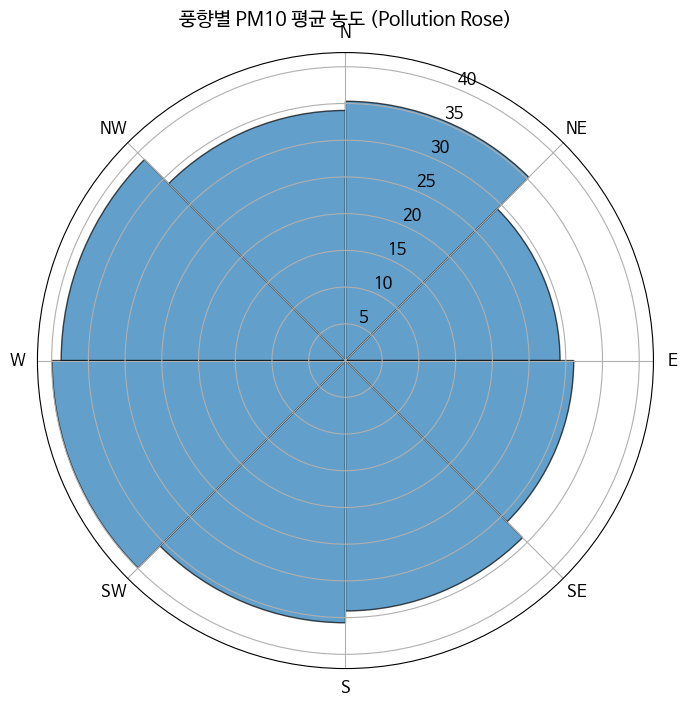

In [33]:
def plot_pollution_rose(
    df,
    pollutant='PM10',
    region=None,      # 문자열 또는 리스트: 특정 '지역'만 보고 싶을 때
    season=None,      # '봄', '여름', '가을', '겨울' 중 하나 또는 리스트
    pm_quantile=None  # 예: 0.8 → 상위 20% 고농도만 사용
):
    """
    df: 최종 통합 데이터프레임
    pollutant: 'PM10' 또는 'PM25' 등
    region: 특정 지역만 필터 ('서울', ['서울', '인천'] 등)
    season: 특정 계절만 필터 ('겨울', ['겨울', '봄'] 등)
    pm_quantile: 상위 quantile 이상만 사용 (고농도 에피소드만 보고 싶을 때)
    """

    data = df.copy()

    # --- 1) 기본 컬럼 존재 여부 체크 ---
    required_cols = ['풍향', pollutant]
    for col in required_cols:
        if col not in data.columns:
            raise ValueError(f"필수 컬럼이 없습니다: {col}")

    # --- 2) 선택적 필터링 ---
    if region is not None and '지역' in data.columns:
        if isinstance(region, str):
            region = [region]
        data = data[data['지역'].isin(region)]

    if season is not None and 'season' in data.columns:
        if isinstance(season, str):
            season = [season]
        data = data[data['season'].isin(season)]

    if pm_quantile is not None:
        thr = data[pollutant].quantile(pm_quantile)
        data = data[data[pollutant] >= thr]

    # --- 3) 풍향 정리 ---
    df_subset = data[['풍향', pollutant]].copy()
    df_subset['풍향'] = (df_subset['풍향'].replace(36, 0)) * 10
    df_subset = df_subset[(df_subset['풍향'] >= 0) & (df_subset['풍향'] < 360)]
    df_subset = df_subset.dropna(subset=['풍향', pollutant])

    if df_subset.empty:
        print("필터 후 사용 가능한 데이터가 없습니다.")
        return

    # --- 4) 풍향 구간(bin) 나누기 (8방위 또는 16방위 선택 가능) ---
    n_sectors = 8
    bins = np.linspace(0, 360, n_sectors + 1)
    labels = [f"{int(bins[i])}~{int(bins[i+1])}" for i in range(n_sectors)]
    df_subset['dir_bin'] = pd.cut(df_subset['풍향'],
                                  bins=bins,
                                  labels=labels,
                                  include_lowest=True,
                                  right=False)

    print(df_subset['dir_bin'])

    grouped = df_subset.groupby('dir_bin')[pollutant].mean().reset_index()

    # --- 5) 극좌표 막대그래프 ---
    angles = []
    for lab in grouped['dir_bin']:
        start, end = lab.split('~')
        angles.append((int(start) + int(end)) / 2)  # 중심각
    values = grouped[pollutant].values

    angles_rad = np.deg2rad(angles)
    width = 2 * np.pi / n_sectors

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, polar=True)

    bars = ax.bar(angles_rad,
                  values,
                  width=width,
                  alpha=0.7,
                  edgecolor='black')

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])

    title = f"풍향별 {pollutant} 평균 농도 (Pollution Rose)"
    if region is not None:
        title += f"\n지역: {region}"
    if season is not None:
        title += f" / 계절: {season}"
    if pm_quantile is not None:
        title += f" / 상위 {int((1 - pm_quantile) * 100)}% 고농도"

    plt.title(title, fontsize=14, pad=20)
    plt.show()


# 예시 실행 (필요에 맞게 바꿔 사용)
# 1) 전체 데이터
plot_pollution_rose(df, pollutant='PM10')

# 2) 겨울 + 서해안 가정: '인천', '군산'만 본다 (존재하는 지역명으로 수정 필요)
# plot_pollution_rose(df, pollutant='PM10', region=['인천', '군산'], season='겨울')

# 3) 상위 20% 고농도일만 대상으로 풍향 분포
# plot_pollution_rose(df, pollutant='PM10', pm_quantile=0.8)


# 분석 2: 기상 요인들이 미세먼지에 미치는 영향

- 기상 요인들이

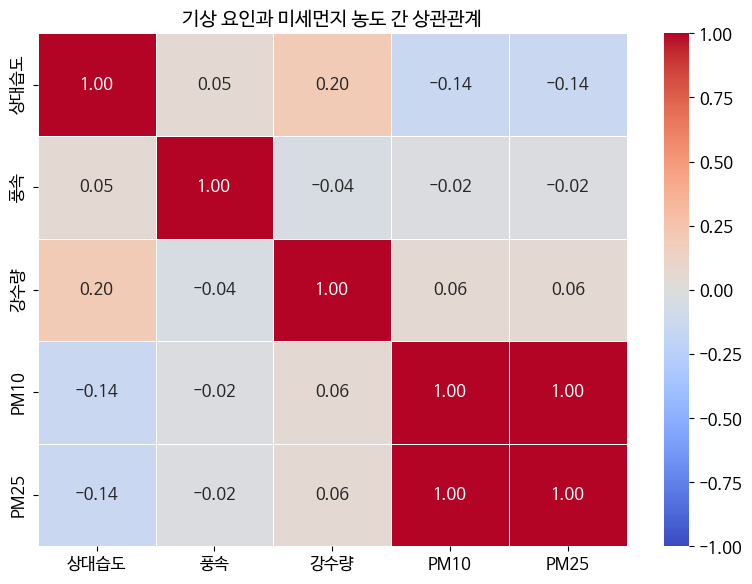

In [17]:
def plot_weather_correlation(df):
  """
  df 안에 존재하는 기상/오염 컬럼만 자동으로 골라서 상관행렬을 그림.
  """
  candidate_weather = ['기온', '상대습도', '습도', '풍속', '강수량', '현지기압', '해면기압']
  candidate_pollutants = ['PM10', 'PM25']

  cols = [c for c in candidate_weather + candidate_pollutants if c in df.columns]

  if len(cols) < 2:
      print("상관 분석에 사용할 컬럼이 부족합니다.")
      return

  corr_df = df[cols].dropna().corr()

  plt.figure(figsize=(8, 6))
  sns.heatmap(corr_df,
              annot=True,
              fmt='.2f',
              cmap='coolwarm',
              vmin=-1, vmax=1,
              linewidths=0.5)
  plt.title("기상 요인과 미세먼지 농도 간 상관관계", fontsize=14)
  plt.tight_layout()
  plt.show()

# 실행 예시
plot_weather_correlation(df)


# 분석 3: 비오는 날에는 실제로 미세먼지 농도가 유의미하게 낮아질까?

In [20]:
# [Cell 4] 비 유무에 따른 PM10 비교 (전체 + 계절별)

from scipy import stats

def compare_rain_effect(df, pollutant='PM10', rain_col='강수량', thr=0.1):
  """
  전체 + 계절별로 비 유무에 따른 PM10(또는 다른 오염물질) 평균 차이와 Welch t-test 수행.
  thr: 강수량이 thr 이상이면 '비 옴'으로 간주.
  """

  def ttest_and_print(sub, label):
    rain = sub[sub[rain_col] >= thr][pollutant].dropna()
    norain = sub[sub[rain_col] < thr][pollutant].dropna()

    if len(rain) < 30 or len(norain) < 30:
      print(f"[{label}] 샘플 수 부족 (rain={len(rain)}, no_rain={len(norain)})")
      return

    t_stat, p_val = stats.ttest_ind(rain, norain, equal_var=False)

    mean_rain = rain.mean()
    mean_norain = norain.mean()
    diff = mean_norain - mean_rain  # 비 안오는 날 - 비 오는 날

    print(f"\n[{label}]")
    print(f"  비 오는 시간대  평균 {pollutant:>5}: {mean_rain:.2f}")
    print(f"  비 안 오는 시간 평균 {pollutant:>5}: {mean_norain:.2f}")
    print(f"  차이 (no_rain - rain): {diff:.2f} μg/m³")
    print(f"  t-statistic: {t_stat:.3f}, p-value: {p_val:.3e}")

    if p_val < 0.05:
        print("결론: 통계적으로 유의한 차이 있음")
    else:
        print("결론: 통계적으로 유의한 차이를 확인하기 어려움")

  # 1) 전체
  ttest_and_print(df, "전체 기간")

  # 2) 계절별
  for s in ['겨울', '봄', '여름', '가을']:
    sub = df[df['계절'] == s]
    if sub.empty:
        continue
    ttest_and_print(sub, f"계절 = {s}")


# 실행 예시
compare_rain_effect(df, pollutant='PM10', rain_col='강수량', thr=0.1)



[전체 기간]
  비 오는 시간대  평균  PM10: 35.21
  비 안 오는 시간 평균  PM10: 31.24
  차이 (no_rain - rain): -3.97 μg/m³
  t-statistic: 24.486, p-value: 5.818e-132
결론: 통계적으로 유의한 차이 있음

[계절 = 겨울]
  비 오는 시간대  평균  PM10: 39.58
  비 안 오는 시간 평균  PM10: 38.79
  차이 (no_rain - rain): -0.79 μg/m³
  t-statistic: 1.251, p-value: 2.109e-01
결론: 통계적으로 유의한 차이를 확인하기 어려움

[계절 = 봄]
  비 오는 시간대  평균  PM10: 49.34
  비 안 오는 시간 평균  PM10: 56.73
  차이 (no_rain - rain): 7.38 μg/m³
  t-statistic: -8.877, p-value: 7.584e-19
결론: 통계적으로 유의한 차이 있음

[계절 = 여름]
  비 오는 시간대  평균  PM10: 23.52
  비 안 오는 시간 평균  PM10: 23.65
  차이 (no_rain - rain): 0.13 μg/m³
  t-statistic: -2.012, p-value: 4.420e-02
결론: 통계적으로 유의한 차이 있음

[계절 = 가을]
  비 오는 시간대  평균  PM10: 28.09
  비 안 오는 시간 평균  PM10: 28.03
  차이 (no_rain - rain): -0.05 μg/m³
  t-statistic: 0.443, p-value: 6.580e-01
결론: 통계적으로 유의한 차이를 확인하기 어려움


In [13]:
# [Cell 4-1] 비 유무 t-test 결과를 표(DataFrame)로 정리

import pandas as pd
from scipy import stats

def compute_rain_season_stats(df, pollutant='PM10', rain_col='강수량', thr=0.1):
    rows = []

    # 1) 전체
    targets = [("전체 기간", df)]
    # 2) 계절별
    for s in ['겨울', '봄', '여름', '가을']:
        sub = df[df['계절'] == s]
        if not sub.empty:
            targets.append((f"계절={s}", sub))

    for label, sub in targets:
        rain = sub[sub[rain_col] >= thr][pollutant].dropna()
        norain = sub[sub[rain_col] < thr][pollutant].dropna()

        if len(rain) < 30 or len(norain) < 30:
            # 샘플 수 너무 적으면 스킵
            continue

        t_stat, p_val = stats.ttest_ind(rain, norain, equal_var=False)

        mean_rain = rain.mean()
        mean_norain = norain.mean()
        std_rain = rain.std()
        std_norain = norain.std()
        n_rain = len(rain)
        n_norain = len(norain)

        diff = mean_norain - mean_rain  # 비 안 오는 날 - 비 오는 날

        rows.append({
            'label': label,
            'mean_rain': mean_rain,
            'mean_norain': mean_norain,
            'std_rain': std_rain,
            'std_norain': std_norain,
            'n_rain': n_rain,
            'n_norain': n_norain,
            'diff_no_minus_rain': diff,
            't_stat': t_stat,
            'p_value': p_val
        })

    stats_df = pd.DataFrame(rows)
    return stats_df


# 실행 예시
rain_stats = compute_rain_season_stats(df, pollutant='PM10', rain_col='강수량', thr=0.1)
display(rain_stats)


,label,mean_rain,mean_norain,std_rain,std_norain,n_rain,n_norain,diff_no_minus_rain,t_stat,p_value
0,전체 기간,35.211105,31.240725,33.734165,47.706268,10569645,86921,-3.970381,24.485862,5.817717e-132
1,계절=겨울,39.578499,38.788898,26.515772,30.171621,2637029,2288,-0.789600,1.251385,2.109218e-01
2,계절=봄,49.341003,56.725632,54.858574,103.386162,2678201,15472,7.384628,-8.877347,7.584270e-19
3,계절=여름,23.524694,23.652254,13.272840,13.082635,2615155,43316,0.127560,-2.012209,4.420389e-02
4,계절=가을,28.088692,28.034281,18.721771,19.675146,2639260,25845,-0.054411,0.442629,6.580379e-01


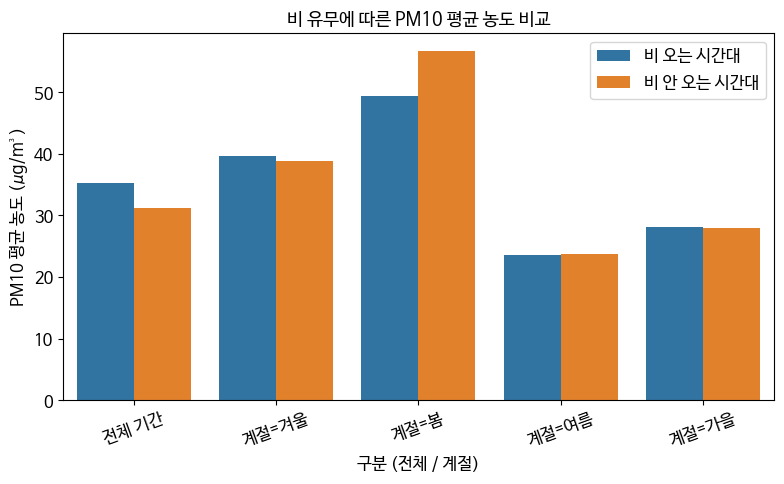

In [14]:
# [Cell 4-2] 비/무강수 평균 PM10 바플롯 (계절별 비교)

import seaborn as sns
import matplotlib.pyplot as plt

def plot_rain_vs_norain_means(rain_stats, pollutant='PM10'):
    """
    compute_rain_season_stats 로 만든 rain_stats를 이용해서
    계절별 비/무강수 평균 PM10 바플롯을 그림.
    """

    # 전체/계절 순서 정리 (있으면 사용, 없으면 그대로 둠)
    order = []
    if '전체 기간' in rain_stats['label'].values:
        order.append('전체 기간')
    for s in ['계절=겨울', '계절=봄', '계절=여름', '계절=가을']:
        if s in rain_stats['label'].values:
            order.append(s)

    plot_df = rain_stats.copy()

    # long 형태로 변환
    plot_df = plot_df.melt(
        id_vars=['label'],
        value_vars=['mean_rain', 'mean_norain'],
        var_name='rain_flag',
        value_name='mean_value'
    )

    plot_df['rain_flag'] = plot_df['rain_flag'].map({
        'mean_rain': '비 오는 시간대',
        'mean_norain': '비 안 오는 시간대'
    })

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=plot_df,
        x='label',
        y='mean_value',
        hue='rain_flag',
        order=order
    )
    plt.xlabel('구분 (전체 / 계절)')
    plt.ylabel(f'{pollutant} 평균 농도 (μg/m³)')
    plt.title(f'비 유무에 따른 {pollutant} 평균 농도 비교', fontsize=13)
    plt.legend(title=None)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


# 실행 예시
plot_rain_vs_norain_means(rain_stats, pollutant='PM10')


# 분석 4: 계절성 / 월별 미세먼지(PM10) 분석

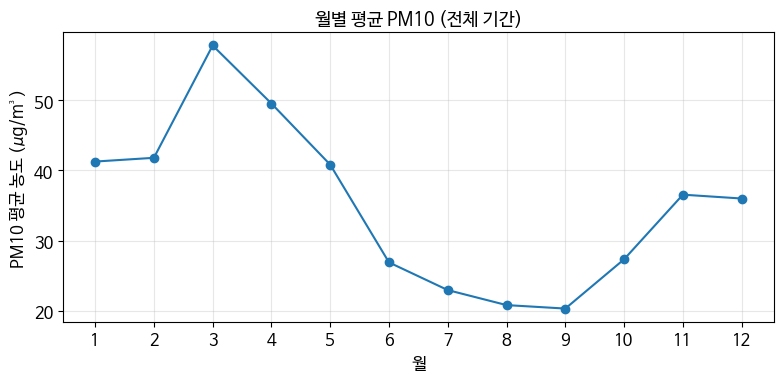

In [24]:
# [Cell 5] 계절성·월별 PM10 분석 (시계열 + 월/계절별 통계)

import matplotlib.pyplot as plt
import seaborn as sns

pollutant = 'PM10'

data = df[['측정일시', '연', '월', '계절', pollutant]].dropna()

# 1) 월별 평균 (전체 기간)
monthly_mean = (data
                .groupby('월')[pollutant]
                .mean()
                .reindex(range(1, 13)))

plt.figure(figsize=(8, 4))
monthly_mean.plot(marker='o')
plt.xticks(range(1, 13))
plt.xlabel('월')
plt.ylabel(f'{pollutant} 평균 농도 (μg/m³)')
plt.title(f'월별 평균 {pollutant} (전체 기간)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

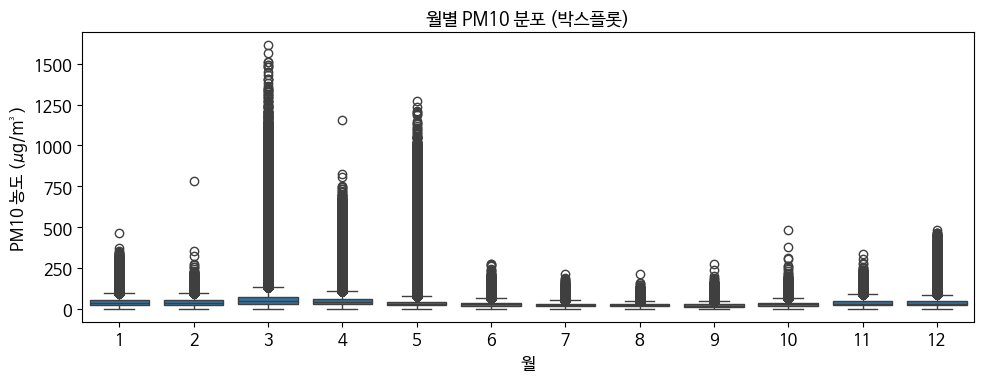

In [25]:
# 2) 월별 박스플롯 (분포 비교)
plt.figure(figsize=(10, 4))
sns.boxplot(data=data, x='월', y=pollutant)
plt.xlabel('월')
plt.ylabel(f'{pollutant} 농도 (μg/m³)')
plt.title(f'월별 {pollutant} 분포 (박스플롯)', fontsize=13)
plt.tight_layout()
plt.show()


[계절별 통계]


,mean,median,std,count
계절,,,,
겨울,39.577808,33.0,26.564734,2639317
봄,49.383427,38.0,55.383121,2693673
여름,23.526772,21.0,13.271859,2658471
가을,28.088163,24.0,18.728981,2665105


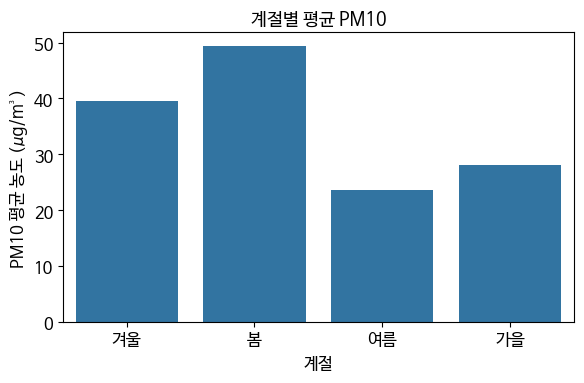

In [26]:
# 3) 계절별 평균
seasonal_stats = (data.groupby('계절')[pollutant]
                      .agg(['mean', 'median', 'std', 'count'])
                      .loc[['겨울', '봄', '여름', '가을']])

print("\n[계절별 통계]")
display(seasonal_stats)

plt.figure(figsize=(6, 4))
sns.barplot(x=seasonal_stats.index, y=seasonal_stats['mean'])
plt.xlabel('계절')
plt.ylabel(f'{pollutant} 평균 농도 (μg/m³)')
plt.title(f'계절별 평균 {pollutant}', fontsize=13)
plt.tight_layout()
plt.show()

/tmp/ipython-input-4173621800.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = data.set_index('측정일시')[pollutant].resample('M').mean()


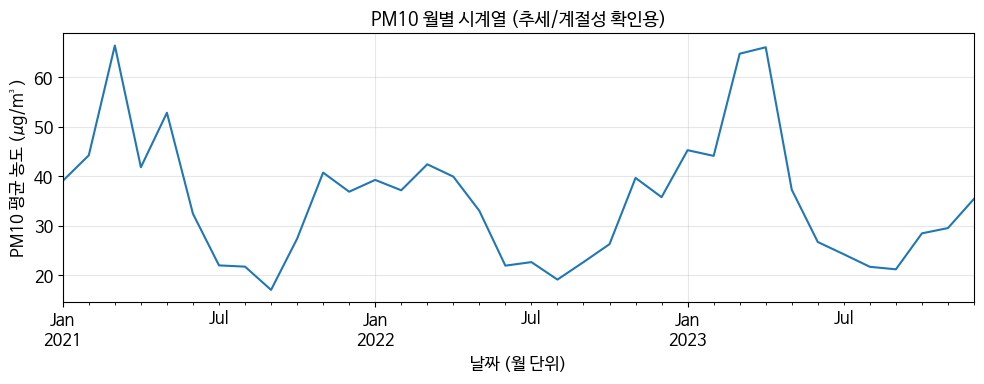

In [27]:
# 4) 월별 시계열 (연도 포함)
ts = data.set_index('측정일시')[pollutant].resample('M').mean()
plt.figure(figsize=(10, 4))
ts.plot()
plt.xlabel('날짜 (월 단위)')
plt.ylabel(f'{pollutant} 평균 농도 (μg/m³)')
plt.title(f'{pollutant} 월별 시계열 (추세/계절성 확인용)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()